# Algebra of sensitivity coefficients

This tutorial focuses exclusively on combining `Sensitivity` objects. It covers scalar operations, powers, uncertainty propagation, and the `raise`, `intersect`, and `zero` metadata policies.

Manipulating algebraically sensitivity coefficients is useful in many applications. Sensitivity coefficients are logarithmic derivatives. Therefore, multiplying two underlying responses adds their sensitivity coefficients, dividing responses subtracts them, and raising a response to a power scales its sensitivity by the exponent.
Also Equivalent Generalised Perturbation Theory (EGPT) demands the manipulation of these sensitivity coefficients.

In [32]:
import os
import sys
import tempfile
from pathlib import Path

os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "matplotlib"))

def find_project_root(start: Path | None = None) -> Path:
    """Find the pyNDUS repository root."""
    start = (start or Path.cwd()).resolve()

    for directory in (start, *start.parents):
        if (
            (directory / "setup.py").is_file()
            and (directory / "src" / "pyNDUS").is_dir()
            and (directory / "docs" / "tutorials").is_dir()
        ):
            return directory

    raise FileNotFoundError(
        f"Could not find the pyNDUS repository root starting from {start}"
    )


PROJECT_ROOT = find_project_root()

SRC_ROOT = PROJECT_ROOT / "src"
if str(SRC_ROOT) not in sys.path:
    sys.path.insert(0, str(SRC_ROOT))

DATA_ROOT = PROJECT_ROOT / "docs" / "tutorials"
SENS_ROOT = DATA_ROOT / "MG_sensitivities" / "serpent"
assert SENS_ROOT.exists(), f"Tutorial sensitivity directory not found: {SENS_ROOT}"

In [33]:
import numpy as np
import matplotlib.pyplot as plt

from pyNDUS import Sensitivity, SensitivityAlgebraError

## Load two sensitivity objects

Jezebel and Godiva use the same 33-group energy structure, responses, material, and MT set, but contain different ZAIDs. This makes them a useful example for the metadata policies.

In [34]:
jezebel = Sensitivity(SENS_ROOT / "jezebel_sens0.m")
godiva = Sensitivity(SENS_ROOT / "godiva_sens0.m")

assert np.array_equal(jezebel.group_structure, godiva.group_structure)
assert set(jezebel.zaid).isdisjoint(godiva.zaid)

print("Jezebel ZAIDs:", tuple(jezebel.zaid))
print("Godiva ZAIDs:", tuple(godiva.zaid))

Jezebel ZAIDs: (942390, 942400, 942410, 310690, 310710)
Godiva ZAIDs: (922350, 922380, 922340)


## Scalar operations and powers

A scalar rescales the average sensitivity. RSDs remain relative, while pyNDUS tracks the absolute uncertainty and its provenance internally. This preserves correlations between expressions derived from the same object.

In [35]:
reconstructed_from_halves = jezebel / 2 + jezebel / 2
np.testing.assert_allclose(reconstructed_from_halves.sens, jezebel.sens)
np.testing.assert_allclose(reconstructed_from_halves.sens_rsd, jezebel.sens_rsd)

# The default metadata policy is `raise`, so select `zero` when metadata differ.
reconstructed_from_powers = jezebel.with_algebra_policy("zero")**1 + godiva**0

for zaid in jezebel.zaid:
    avg, rsd = reconstructed_from_powers.get(za=zaid)
    original_avg, original_rsd = jezebel.get(za=zaid)
    np.testing.assert_allclose(avg, original_avg)
    np.testing.assert_allclose(rsd, original_rsd)

Without `with_algebra_policy("zero")`, the expression would use the default `raise` policy and reject the different ZAID sets. `S**0` means the sensitivity of a response raised to power zero, so both its average and uncertainty contributions are zero.

## Metadata policy: `raise`

`raise` is the safe default. It accepts different axis orderings, but all response, material, ZAID, and MT sets must be equal.

In [36]:
try:
    jezebel + godiva
except SensitivityAlgebraError as error:
    print(error)
else:
    raise AssertionError("The different ZAID sets should be rejected by policy='raise'")

Sensitivity metadata differ with policy='raise': zaid: only left=(942390, 942400, 942410, 310690, 310710), only right=(922350, 922380, 922340)


## Metadata policy: `intersect`

`intersect` retains only metadata shared by both objects. If an entire axis has no common value, there is no valid profile to return and pyNDUS raises an informative error.

In [37]:
try:
    jezebel.combine(godiva, policy="intersect")
except SensitivityAlgebraError as error:
    assert "No common zaid" in str(error)
    print(error)

No common zaid available with policy='intersect'.


## Metadata policy: `zero`

`zero` retains the union of each metadata axis. A profile missing from either operand is expanded to average zero and standard deviation zero before the operation. Consequently, a ZAID available only in one object is preserved unchanged by addition.

In [38]:
total = jezebel.combine(godiva, operation="add", policy="zero")

expected_zaids = tuple(jezebel.zaid) + tuple(godiva.zaid)
assert tuple(total.zaid) == expected_zaids
assert total.sens.shape[2] == jezebel.n_zai + godiva.n_zai

for source in (jezebel, godiva):
    for zaid in source.zaid:
        total_avg, total_rsd = total.get(za=zaid)
        source_avg, source_rsd = source.get(za=zaid)
        np.testing.assert_allclose(total_avg, source_avg)
        np.testing.assert_allclose(total_rsd, source_rsd)

print("Combined ZAIDs:", tuple(total.zaid))

Combined ZAIDs: (942390, 942400, 942410, 310690, 310710, 922350, 922380, 922340)


The same policy works when responses, materials, or MTs are missing. The result keeps their ordered union: values from the left object come first, followed by values found only on the right.

## Response products and ratios

For logarithmic sensitivity coefficients, operators between two objects refer to the underlying responses: `S1 * S2` is `S1 + S2`, while `S1 / S2` is `S1 - S2`. The explicit `combine` method is useful when a metadata policy must be supplied.

In [39]:
product_sensitivity = jezebel.combine(godiva, operation="multiply", policy="zero")
ratio_sensitivity = jezebel.combine(godiva, operation="divide", policy="zero")

pu239 = next(iter(jezebel.zaid))
u235 = next(iter(godiva.zaid))

np.testing.assert_allclose(product_sensitivity.get(za=pu239)[0], jezebel.get(za=pu239)[0])
np.testing.assert_allclose(ratio_sensitivity.get(za=pu239)[0], jezebel.get(za=pu239)[0])
np.testing.assert_allclose(product_sensitivity.get(za=u235)[0], godiva.get(za=u235)[0])
np.testing.assert_allclose(ratio_sensitivity.get(za=u235)[0], -godiva.get(za=u235)[0])

## Visual check

The profiles below are selected from the union object. Since each ZAID occurs in only one source, the curves coincide exactly with their original profiles.

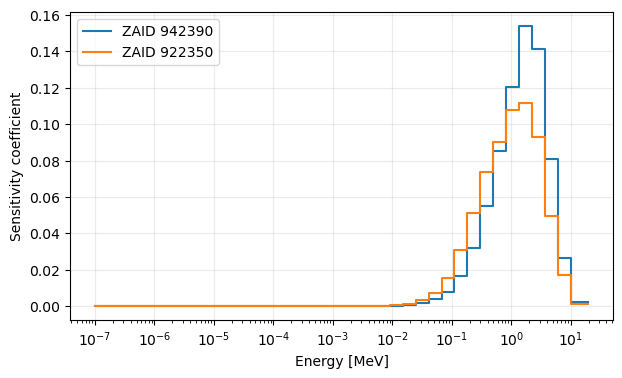

In [40]:
energy = total.group_structure[1:]
pu_profile = total.get(resp="keff", mat="total", MT=18, za=pu239)[0].squeeze()
u_profile = total.get(resp="keff", mat="total", MT=18, za=u235)[0].squeeze()

fig, ax = plt.subplots(figsize=(7, 4))
ax.step(energy, pu_profile, where="pre", label=f"ZAID {pu239}")
ax.step(energy, u_profile, where="pre", label=f"ZAID {u235}")
ax.set_xscale("log")
ax.set_xlabel("Energy [MeV]")
ax.set_ylabel("Sensitivity coefficient")
ax.legend()
ax.grid(alpha=0.25)
plt.show()

Let's verify that a profile divided by a factor 2 yields consistent values:

/var/folders/cr/cbff3g9d5csf_mnzcds9k9680000gp/T/ipykernel_65798/1909526630.py:12: RuntimeWarning: invalid value encountered in divide
  ax2.step(energy, pu_profile / pu_profile_half, where="pre", label=f"ratio", c="r")


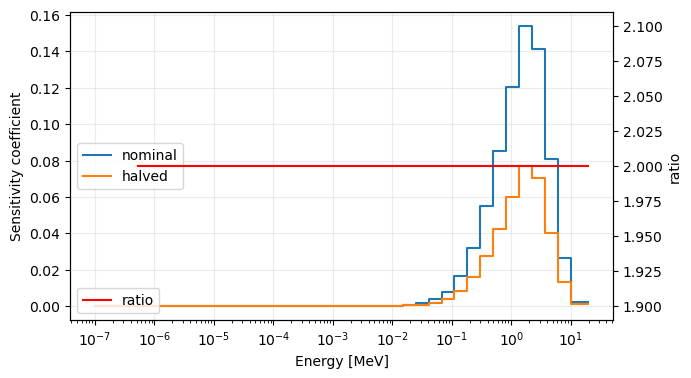

In [41]:
jezebel_half = jezebel / 2

energy = total.group_structure[1:]
pu_profile = jezebel.get(resp="keff", mat="total", MT=18, za=pu239)[0].squeeze()
pu_profile_half = jezebel_half.get(resp="keff", mat="total", MT=18, za=pu239)[0].squeeze()

fig, ax = plt.subplots(figsize=(7, 4))
ax.step(energy, pu_profile, where="pre", label=f"nominal")
ax.step(energy, pu_profile_half, where="pre", label=f"halved")

ax2 = ax.twinx()
ax2.step(energy, pu_profile / pu_profile_half, where="pre", label=f"ratio", c="r")
ax2.set_ylabel("ratio")

ax.set_xscale("log")
ax.set_xlabel("Energy [MeV]")
ax.set_ylabel("Sensitivity coefficient")
ax.legend(loc="center left")
ax2.legend(loc="lower left")

ax.grid(alpha=0.25)
plt.show()

## Summary

- Use scalar arithmetic and powers to transform one sensitivity object.
- Use ordinary operators when metadata are identical.
- Use `combine(..., policy="intersect")` to retain only common metadata.
- Use `combine(..., policy="zero")` to retain the union and interpret missing profiles as deterministic zero.
- Energy-group boundaries must always match.